In [ ]:
!pip install transformers accelerate torch

!pip install git+https://github.com/huggingface/diffusers.git

  Cloning https://github.com/huggingface/diffusers.git to /tmp/pip-req-build-rfygi98y
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers.git /tmp/pip-req-build-rfygi98y
  Resolved https://github.com/huggingface/diffusers.git to commit eeae0338e7ad2b3749eac0c8701ec250a1884844
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for diffusers: filename=diffusers-0.36.0.dev0-py3-none-any.whl size=4452357 sha256=a618f8c365c0def43d24b55b1c3dd5f3330690b3502fe22f132e7dd214abf1f0
  Stored in directory: /tmp/pip-ephem-wheel-cache-xwo_sa94/wheels/23/0f/7d/f97813d265ed0e599a78d83afd4e1925740896ca79b46cccfd
Successfully built diffusers
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.35.2
    Uninstalling diffusers-0.35.2:
      Successfully uninstalled diffusers-0.35.2


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

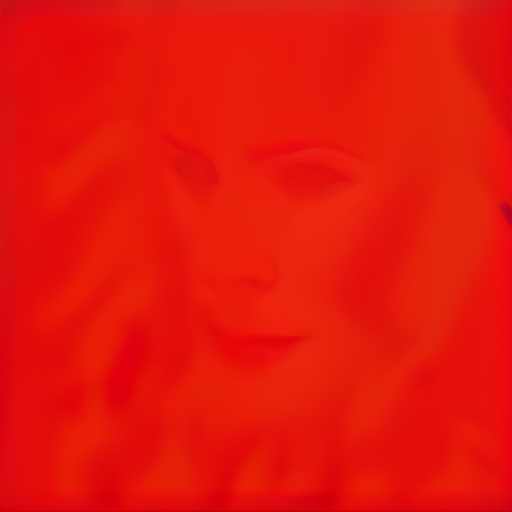

In [ ]:
import torch
from diffusers import StableDiffusionInstructPix2PixPipeline, EulerAncestralDiscreteScheduler
from PIL import Image

model_id = "/content/drive/MyDrive/insp2p_makeup100_mdl"
# Adjusted to run on GPU with float16 for A100 compatibility
pipe = StableDiffusionInstructPix2PixPipeline.from_pretrained(model_id, torch_dtype=torch.float16, safety_checker=None)
pipe.to("cuda")
pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)

# Placeholder for image input. Please load your image here.
# Example: image = Image.open("path/to/your/image.jpg").convert("RGB")
image = Image.new('RGB', (512, 512), color = 'red') # Placeholder: Replace with your actual image

images = pipe("turn him into cyborg", image=image).images
images[0]

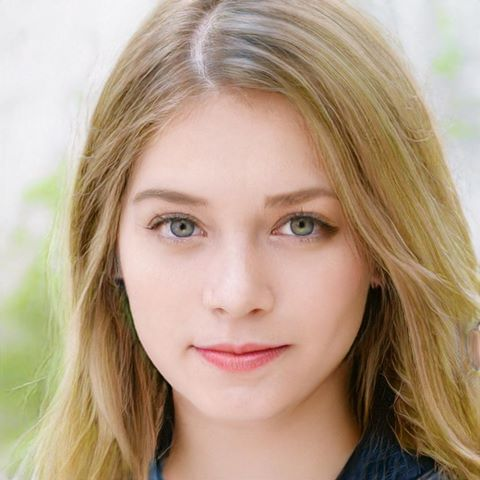

In [ ]:
import requests
from PIL import Image
from io import BytesIO

image_url = "https://chris.dilger.me/content/images/2019/07/face.jpg"
response = requests.get(image_url)
image_from_url = Image.open(BytesIO(response.content)).convert("RGB")

# Now, you can use 'image_from_url' as your input image.
# For example, replace 'image = Image.new(...)' in the previous cell with:
# image = image_from_url

display(image_from_url)

  0%|          | 0/100 [00:00<?, ?it/s]

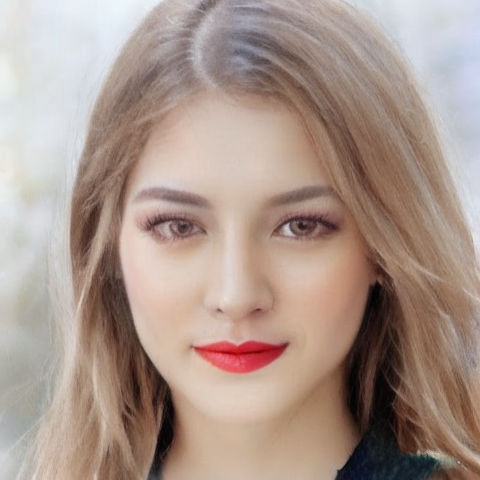

In [ ]:
image = image_from_url

images = pipe("apply light foundation, red lips, and natural makeup", image=image).images
images[0]

  0%|          | 0/100 [00:00<?, ?it/s]

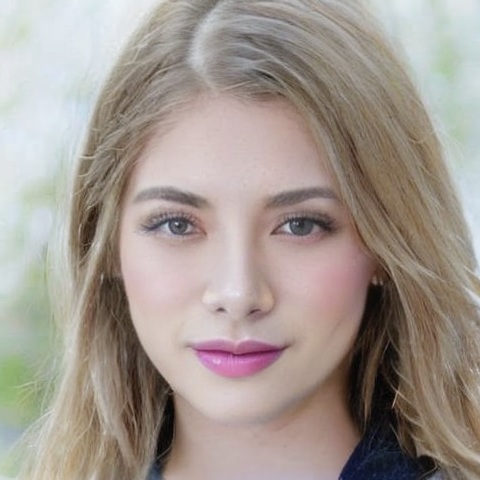

In [ ]:
images = pipe("Apply natural foundation, define brows, add vibrant lips, create a playful style.", image=image).images
images[0]

In [ ]:
import os

base_dir = "/content/drive/MyDrive/data_sampled"
input_folder = "base_images_sampled"
output_folder = "edited_sampled_deng"
prompts_file = "prompts_sampled.txt"

output_path = os.path.join(base_dir, output_folder)
os.makedirs(output_path, exist_ok=True)

print(f"Base directory: {base_dir}")
print(f"Input folder: {input_folder}")
print(f"Output folder: {output_folder}")
print(f"Prompts file: {prompts_file}")
print(f"Output path created/verified: {output_path}")

Base directory: /content/drive/MyDrive/data_sampled
Input folder: base_images_sampled
Output folder: edited_sampled_deng
Prompts file: prompts_sampled.txt
Output path created/verified: /content/drive/MyDrive/data_sampled/edited_sampled_deng


In [ ]:
from PIL import Image
import os

# Construct full paths
input_dir = os.path.join(base_dir, input_folder)
prompts_file_path = os.path.join(base_dir, prompts_file)

# 1. Load prompts from the text file
try:
    with open(prompts_file_path, 'r') as f:
        prompts = [line.strip() for line in f if line.strip()]
    print(f"Loaded {len(prompts)} prompts from {prompts_file_path}")
except FileNotFoundError:
    print(f"Error: Prompts file not found at {prompts_file_path}")
    prompts = []

# Get list of image files in the input folder
image_files = [f for f in os.listdir(input_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
image_files.sort() # Ensure consistent order

if not image_files:
    print(f"No image files found in {input_dir}")
elif len(image_files) != len(prompts):
    print(f"Warning: Number of images ({len(image_files)}) does not match number of prompts ({len(prompts)}).")
    print("Processing will continue, but ensure prompts and images correspond correctly.")

# 2. Iterate through images, apply prompts, and save results
print(f"Starting bulk inference for {len(image_files)} images...")
for i, image_filename in enumerate(image_files):
    if i < len(prompts): # Only process if a corresponding prompt exists
        image_path = os.path.join(input_dir, image_filename)
        current_prompt = prompts[i]

        try:
            original_image = Image.open(image_path).convert("RGB")
            print(f"Processing image {i+1}/{len(image_files)}: {image_filename} with prompt: '{current_prompt}'")

            # Perform inference
            edited_images = pipe(current_prompt, image=original_image).images
            edited_image = edited_images[0]

            # Save the edited image
            output_filename = f"edited_{os.path.splitext(image_filename)[0]}.png" # Save as PNG
            output_image_path = os.path.join(output_path, output_filename)
            edited_image.save(output_image_path)
            print(f"Saved edited image to: {output_image_path}")

        except Exception as e:
            print(f"Error processing {image_filename}: {e}")
    else:
        print(f"Skipping image {image_filename}: No corresponding prompt found.")

print("Bulk inference completed.")

Loaded 100 prompts from /content/drive/MyDrive/data_sampled/prompts_sampled.txt
Starting bulk inference for 100 images...
Processing image 1/100: 000045.jpg with prompt: 'Apply foundation, define brows, add bold lips, and enhance with eyeshadow and blush to achieve a dramatic look.'


  0%|          | 0/100 [00:00<?, ?it/s]

Saved edited image to: /content/drive/MyDrive/data_sampled/edited_sampled_deng/edited_000045.png
Processing image 2/100: 000107.jpg with prompt: 'Apply natural foundation, define brows, add bold lips, achieve sleek style.'


  0%|          | 0/100 [00:00<?, ?it/s]

Saved edited image to: /content/drive/MyDrive/data_sampled/edited_sampled_deng/edited_000107.png
Processing image 3/100: 000150.jpg with prompt: 'Apply natural foundation, define brows, add subtle lip color, achieve elegant style.'


...

Saved edited image to: /content/drive/MyDrive/data_sampled/edited_sampled_deng/edited_002936.png
Processing image 99/100: 002952.jpg with prompt: 'Apply gray foundation, define brows with pencil, add pink lips, and achieve a sallow, aged style.'


  0%|          | 0/100 [00:00<?, ?it/s]

Saved edited image to: /content/drive/MyDrive/data_sampled/edited_sampled_deng/edited_002952.png
Processing image 100/100: 002987.jpg with prompt: 'Apply foundation, define brows, add yellow or red lips, and enhance with subtle eye makeup for a classic or bold look.'


  0%|          | 0/100 [00:00<?, ?it/s]

Saved edited image to: /content/drive/MyDrive/data_sampled/edited_sampled_deng/edited_002987.png
Bulk inference completed.


  0%|          | 0/100 [00:00<?, ?it/s]

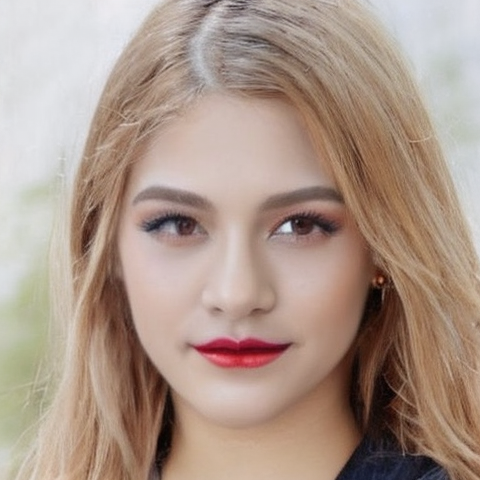

In [ ]:
images = pipe("Apply natural foundation, define brows, add bold red lips, and enhance with dramatic eye makeup to achieve an intense look.", image=image).images
images[0]